# Cooldown Model

This notebook contains one reduced-order model for the dissertation: a steady HFE-side heat-flux calculation for the heat exchanger length requirement, plus an analytic lumped-capacitance cooldown estimate.

Design point used throughout:

- Bulk HFE target: `-110 C`
- HFE freezing / minimum HX wall temperature: `-121 C`
- Design heat leak at the target: `200 W`
- Room / ambient temperature: `25 C`
- Installed heat exchanger: `6 m` of `1/4 in OD`, `0.05 in wall` stainless tubing
- Nominal HFE-side coefficient: `250 W m^-2 K^-1`, rounded from a conservative low-Re cylinder cross-flow estimate
- HFE inventory basis: fixed volume of `2.8 L + 260 mL = 3.06 L`, with mass derived from the HFE-7200 density law
- HFE heat-capacity basis: HFE-7200 `c_p(25 C) = 1220 J kg^-1 K^-1`, scaled with the HFE-7000 temperature dependence and averaged over the cooldown path

The heat-leak note in `analysis/docs/Heat_Leak_Calculations.pdf` estimates the system heat leak to be of order `188 W` at a similar cold operating point. This notebook uses `200 W` as a rounded conservative design value.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

nb_path = Path.cwd()
repo_root = nb_path
for candidate in [nb_path, *nb_path.parents]:
    if (candidate / "analysis").exists() and (candidate / "data").exists():
        repo_root = candidate
        break

src_dir = repo_root / "analysis" / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

import orca

DISSERTATION_FONT_SIZE = 14
DISSERTATION_LABEL_SIZE = 16
DISSERTATION_TITLE_SIZE = 17
DISSERTATION_TICK_SIZE = 13
DISSERTATION_LEGEND_SIZE = 12
DISSERTATION_ANNOTATION_SIZE = 12

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "font.size": DISSERTATION_FONT_SIZE,
        "axes.titlesize": DISSERTATION_TITLE_SIZE,
        "axes.labelsize": DISSERTATION_LABEL_SIZE,
        "xtick.labelsize": DISSERTATION_TICK_SIZE,
        "ytick.labelsize": DISSERTATION_TICK_SIZE,
        "legend.fontsize": DISSERTATION_LEGEND_SIZE,
        "legend.title_fontsize": DISSERTATION_LEGEND_SIZE,
        "figure.titlesize": DISSERTATION_TITLE_SIZE,
        "axes.titlepad": 10.0,
        "axes.labelpad": 8.0,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


## Model Equations

The length calculation is governed by the HFE-side heat flux into the outside of the tube. For tube outside area

$$
A_o = \pi d_o L,
$$

the installed HFE-side conductance is

$$
UA_{\mathrm{HX}} = h_{\mathrm{HFE}} A_o.
$$

At the target, the coil must remove the heat leak without driving the outside wall below the freezing / protection temperature. The minimum length is therefore

$$
L_{\mathrm{req}} = \frac{\dot Q_{\mathrm{leak}}}{\pi d_o h_{\mathrm{HFE}} (T_{\mathrm{target}} - T_{\mathrm{freeze}})}.
$$

The nominal `h_HFE` is treated as an effective liquid-side coefficient rather than a material property. The value used here is `250 W m^-2 K^-1`, rounded from a Churchill-Bernstein cylinder cross-flow estimate. In that estimate, `Pr = 46` and `k = 0.0974 W m^-1 K^-1` come from `HowLowCanYouGo.pdf`, Tables 1 and 2, for HFE-7000 at `-90 C`; they are used only as an HFE-family low-temperature surrogate because matching HFE-7200 values at `-110 C` are not available in the local data. The characteristic diameter is the installed `1/4 in` tube outside diameter, `D = 0.00635 m`. The article reports HFE-7000 testing at `Re ≈ 3900`, while this notebook deliberately uses `Re_D = 50` as a conservative weak-mixing basis.

The HFE-7200 inventory is set by fixed liquid volume rather than a fixed mass. The model uses

$$
V_{\mathrm{HFE}} = 2.8\,\mathrm{L} + 0.260\,\mathrm{L} = 3.06\,\mathrm{L},
\qquad
m_{\mathrm{HFE}}(T) = V_{\mathrm{HFE}}\rho_{7200}(T).
$$

The HFE-7200 heat capacity is anchored to the known 25 C value and scaled with the HFE-7000 temperature trend from the property notebook:

$$
c_{p,7000}(T) = 1223.2 + 3.0803T,
$$

$$
c_{p,7200}(T) = 1220\,\frac{c_{p,7000}(T)}{c_{p,7000}(25^\circ\mathrm{C})}.
$$

The cooldown time comes from the one-node energy balance

$$
C\frac{dT}{dt} = UA_{\mathrm{amb}}(T_{\mathrm{amb}} - T) - UA_{\mathrm{HX}}(T - T_{\mathrm{freeze}}),
$$

where

$$
UA_{\mathrm{amb}} = \frac{200\,\mathrm{W}}{T_{\mathrm{amb}} - T_{\mathrm{target}}},\qquad
C = V_{\mathrm{HFE}}\,\overline{\rho c_p}_{\mathrm{HFE}}.
$$

The effective fixed-volume heat capacity is the path average over the cooldown:

$$
\overline{\rho c_p}_{\mathrm{HFE}} = \frac{1}{T_0 - T_{\mathrm{target}}}\int_{T_{\mathrm{target}}}^{T_0} \rho_{7200}(T)c_{p,7200}(T)\,dT.
$$

The ODE solution remains analytic because this path-averaged heat capacity is treated as constant for the reduced-order estimate:

$$
T(t) = T_{\mathrm{eq}} + (T_0 - T_{\mathrm{eq}})e^{-t/\tau},
$$

with

$$
T_{\mathrm{eq}} = \frac{UA_{\mathrm{amb}}T_{\mathrm{amb}} + UA_{\mathrm{HX}}T_{\mathrm{freeze}}}{UA_{\mathrm{amb}} + UA_{\mathrm{HX}}},
\qquad
\tau = \frac{C}{UA_{\mathrm{amb}} + UA_{\mathrm{HX}}}.
$$

Solving this expression for `T = -110 C` gives the cooldown time. LN2 consumption is computed from the analytic time integral of `Q_HX(t)` divided by the 10 bar latent heat, `165 kJ/kg`.


In [2]:
inputs = orca.default_cooldown_design_inputs()
result = orca.simulate_simple_cooldown(inputs)

hfe_htc_values = np.array([100.0, 125.0, 150.0, 170.0, 200.0, 250.0, 300.0])
sensitivity = orca.cooldown_sensitivity_table(hfe_htc_values, inputs)
history = result.history_frame()

hfe_htc_basis = orca.nominal_hfe_htc_basis(inputs.tube_outer_diameter_m)

summary = pd.DataFrame(
    {
        "quantity": [
            "HFE inventory volume (L)",
            "HFE mass at 25 C from volume (kg)",
            "HFE mass at -110 C from volume (kg)",
            "Scaled HFE-7200 cp at 25 C (J/kg/K)",
            "Scaled HFE-7200 cp at -110 C (J/kg/K)",
            "Path-average HFE-7200 cp (J/kg/K)",
            "Path-average HFE-7200 rho*cp (MJ/m^3/K)",
            "HTC basis Re_D, reduced from article Re~3900",
            "HTC basis Pr, HFE-7000 at -90 C",
            "HTC basis k, HFE-7000 at -90 C (W/m/K)",
            "HTC basis D, 1/4 in tube OD (m)",
            "Churchill-Bernstein Nu_D basis",
            "Churchill-Bernstein h basis (W/m^2/K)",
            "Nominal h_HFE used, rounded (W/m^2/K)",
            "Critical h_HFE for installed 6 m (W/m^2/K)",
            "Installed HX area (m^2)",
            "Required length at nominal h_HFE (m)",
            "Installed HX length (m)",
            "Installed length margin",
            "Required HFE-side UA (W/K)",
            "Installed HFE-side UA (W/K)",
            "Wall temperature at 200 W (C)",
            "Equilibrium bulk temperature (C)",
            "Thermal time constant (min)",
            "Time to -110 C (min)",
            "Energy removed to target (MJ)",
            "LN2 to target, 10 bar latent only (kg)",
            "Steady LN2 flow for 200 W at 10 bar (L/min)",
        ],
        "value": [
            inputs.hfe_volume_l,
            result.hfe_mass_room_kg,
            result.hfe_mass_target_kg,
            result.hfe_cp_room_j_kg_k,
            result.hfe_cp_target_j_kg_k,
            result.hfe_cp_effective_j_kg_k,
            result.hfe_volumetric_heat_capacity_effective_j_m3_k / 1e6,
            hfe_htc_basis.reynolds,
            hfe_htc_basis.prandtl,
            hfe_htc_basis.thermal_conductivity_w_m_k,
            hfe_htc_basis.diameter_m,
            hfe_htc_basis.nusselt,
            hfe_htc_basis.h_basis_w_m2_k,
            hfe_htc_basis.nominal_h_w_m2_k,
            result.critical_hfe_htc_w_m2_k,
            result.installed_area_m2,
            result.required_length_m,
            inputs.installed_length_m,
            result.installed_margin,
            result.required_hfe_ua_w_per_k,
            result.installed_hfe_ua_w_per_k,
            result.wall_temp_at_200w_c,
            result.equilibrium_temp_c,
            result.thermal_time_constant_min,
            result.time_to_target_min,
            result.energy_to_target_mj,
            result.ln2_to_target_kg,
            result.ln2_hold_volume_flow_lpm,
        ],
    }
)

summary.round(3)


,quantity,value
0,HFE inventory volume (L),3.060
1,HFE mass at 25 C from volume (kg),4.356
2,HFE mass at -110 C from volume (kg),5.307
3,Scaled HFE-7200 cp at 25 C (J/kg/K),1220.000
4,Scaled HFE-7200 cp at -110 C (J/kg/K),829.812
5,Path-average HFE-7200 cp (J/kg/K),1024.906
6,Path-average HFE-7200 rho*cp (MJ/m^3/K),1.608
7,"HTC basis Re_D, reduced from article Re~3900",50.000
8,"HTC basis Pr, HFE-7000 at -90 C",46.000
9,"HTC basis k, HFE-7000 at -90 C (W/m/K)",0.097


The HFE inventory is treated as a volume reference instead of a prescribed mass. The model therefore uses

$$
V_{\mathrm{HFE}} = 2.8\,\mathrm{L} + 0.260\,\mathrm{L},\qquad m(T)=V_{\mathrm{HFE}}\rho(T),
$$

so the mass reported at each temperature is calculated from the density law and the `3.06 L` volume basis.

The heat capacity is also temperature adjusted without making the cooldown model nonlinear. HFE-7200 is anchored at the known `25 C` value, `1220 J kg^-1 K^-1`, and the temperature trend is scaled from the HFE-7000 relation in `HFE_properties.ipynb`. The lumped model then uses the path-average volumetric heat capacity between `25 C` and `-110 C`.


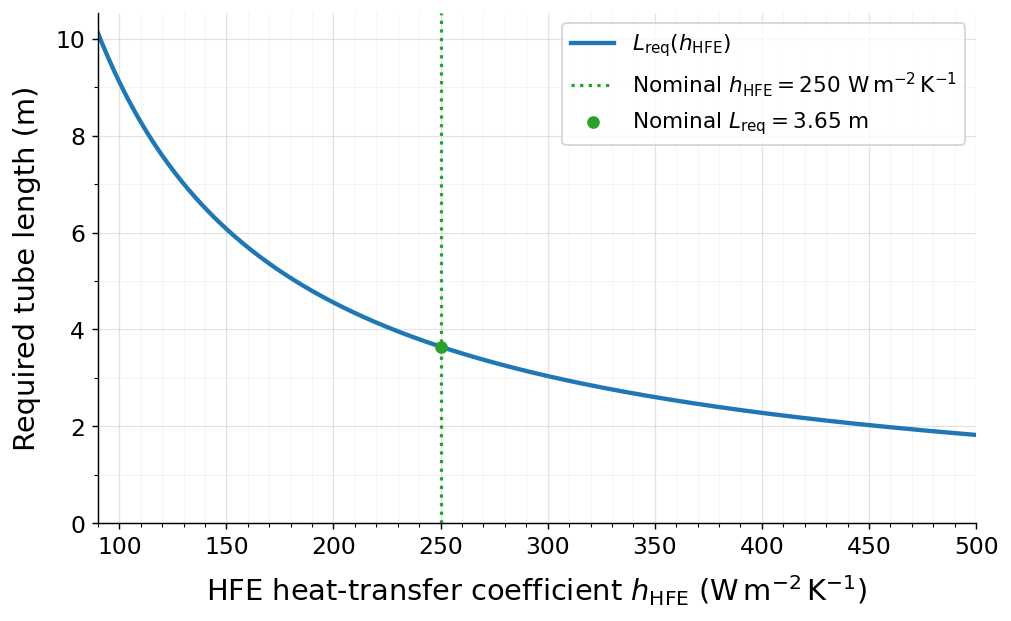

,h_HFE_W_m2_K,required_length_m,installed_margin,wall_temp_at_200w_C,equilibrium_temp_C,time_to_target_min,energy_to_target_MJ,ln2_to_target_kg
0,100.0,9.11,0.66,-126.7,-104.92,NaN,NaN,NaN
1,125.0,7.29,0.82,-123.4,-107.85,NaN,NaN,NaN
2,150.0,6.08,0.99,-121.1,-109.87,NaN,NaN,NaN
3,170.0,5.36,1.12,-119.8,-111.09,18.1,0.839,5.08
4,200.0,4.56,1.32,-118.4,-112.49,12.9,0.784,4.75
5,250.0,3.65,1.65,-116.7,-114.11,9.2,0.747,4.53
6,300.0,3.04,1.97,-115.6,-115.22,7.2,0.728,4.41


In [3]:
from matplotlib.ticker import AutoMinorLocator

length_grid_h = np.linspace(90.0, 500.0, 800)
length_grid_m = np.array(
    [
        orca.required_hx_length_m(
            heat_leak_w=inputs.heat_leak_target_w,
            tube_outer_diameter_m=inputs.tube_outer_diameter_m,
            hfe_htc_w_m2_k=h,
            target_temp_c=inputs.target_temp_c,
            freeze_temp_c=inputs.freeze_temp_c,
        )
        for h in length_grid_h
    ]
)

fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.plot(length_grid_h, length_grid_m, color="C0", lw=2.4, label=r"$L_{\mathrm{req}}(h_{\mathrm{HFE}})$")
ax.axvline(
    inputs.hfe_htc_w_m2_k,
    color="C2",
    ls=":",
    lw=1.8,
    label=rf"Nominal $h_{{\mathrm{{HFE}}}}={inputs.hfe_htc_w_m2_k:.0f}\ \mathrm{{W\,m^{{-2}}\,K^{{-1}}}}$",
)
ax.scatter(
    [inputs.hfe_htc_w_m2_k],
    [result.required_length_m],
    color="C2",
    zorder=5,
    label=rf"Nominal $L_{{\mathrm{{req}}}}={result.required_length_m:.2f}\ \mathrm{{m}}$",
)
ax.set_xlabel(r"HFE heat-transfer coefficient $h_{\mathrm{HFE}}$ ($\mathrm{W\,m^{-2}\,K^{-1}}$)")
ax.set_ylabel("Required tube length (m)")
ax.set_xlim(90.0, 500.0)
ax.set_ylim(bottom=0.0)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major", alpha=0.35, lw=0.7)
ax.grid(True, which="minor", alpha=0.16, lw=0.45)
ax.legend()
plt.tight_layout()
plt.show()

sensitivity.round(
    {
        "h_HFE_W_m2_K": 0,
        "required_length_m": 2,
        "installed_margin": 2,
        "wall_temp_at_200w_C": 1,
        "equilibrium_temp_C": 2,
        "time_to_target_min": 1,
        "energy_to_target_MJ": 3,
        "ln2_to_target_kg": 2,
    }
)


## Heat Exchanger Geometry Check

The final exchanger is represented as a central inlet riser plus a helical coil inside the main tank body. The tank geometry used for this figure is the corrected `309.5 mm` high main cylinder with `96 mm` inner diameter. The simplified side view omits the lower stub and uses the main-body wall only.

The selected coil envelope is `80 mm` OD, leaving `8 mm` radial clearance inside the main body. The side-view layout accounts for the real `1/4 in` tube OD by drawing the tube as finite-width bands, then sizes the centerline length to the minimum required by the cooling model instead of using the full installed `6 m` tube budget. The optimized layout is a `14`-turn coil with about `15.52 mm` pitch, about `9.17 mm` axial gap between tube OD bands, and about `3.65 m` of modeled in-tank tube length. The top of the central riser is the inlet; the riser stops at the bottom of the coil, and the coil outlet bridges sideways before rising to the offset outlet.

The specified `2.8 L` tank volume is retained as the mechanical usable HFE volume stated for the main vessel, and the cooldown model adds `260 mL` outside the vessel for a `3.06 L` inventory basis. A full `309.5 mm` by `96 mm` cylinder alone holds about `2.24 L`, so neither volume is drawn as an internal liquid level in this simplified main-body-only sketch.

,quantity,value,check
0,Main body inner diameter (m),0.0960,96 mm tank ID
1,Main body height (m),0.3095,corrected 309.5 mm main cylinder
2,Tank mechanical usable volume (L),2.8000,2.8 L tank volume reference
3,Cooldown-model HFE inventory volume (L),3.0600,2.8 L tank + 260 mL added volume
4,Full main-body cylinder volume (L),2.2402,main-body-only volume; smaller than usable spec
5,Equivalent 96 mm-body fill height (m),0.3868,exceeds main height; not drawn as fill line
6,Coil tube outer diameter envelope (m),0.0800,80 mm coil tube envelope
7,Coil active OD height (m),0.2236,cooling-model minimum length layout
8,Coil OD width / active OD height,0.3578,real 80 mm width over required axial height
9,Coil centerline diameter (m),0.0737,centerline = envelope - tube OD


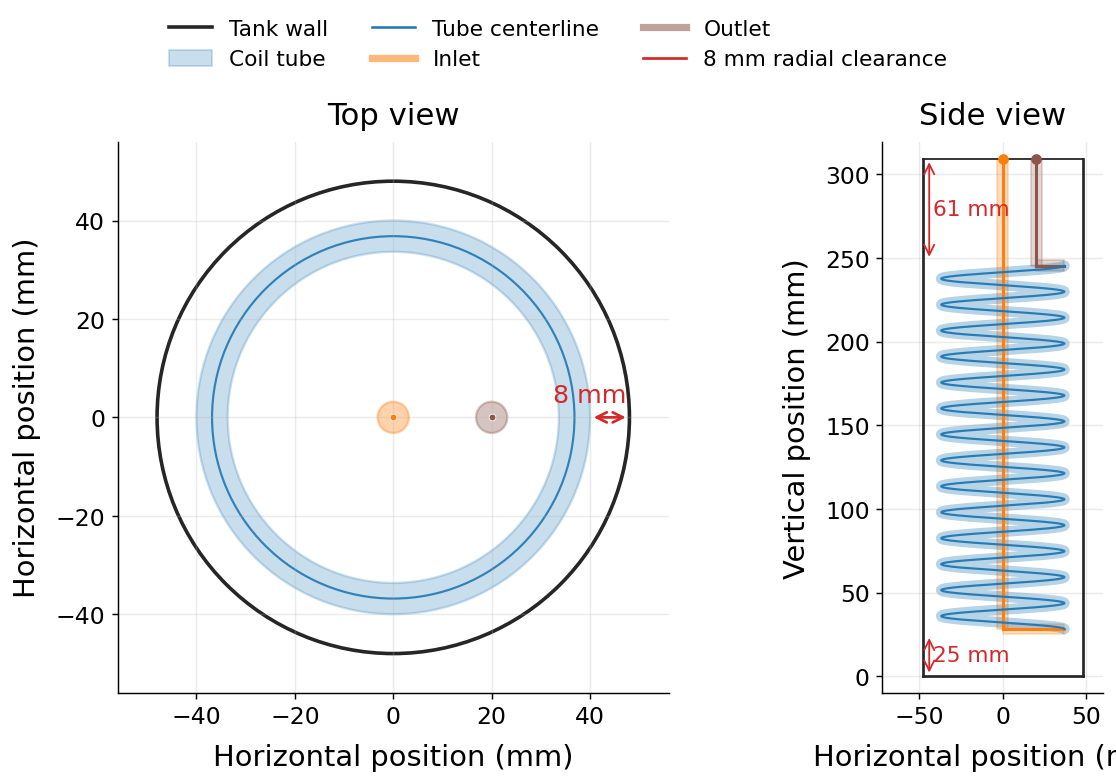

In [4]:
# Heat exchanger geometry schematic
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch, Wedge

system = orca.default_system_model()
tank_main_inner_diameter_m = system.tank.inner_diameter_m
tank_main_radius_m = system.tank.inner_radius_m
tank_main_height_m = 0.3095
usable_hfe_volume_m3 = system.tank_liquid_volume_m3
main_body_area_m2 = np.pi * tank_main_radius_m**2
main_body_full_volume_m3 = main_body_area_m2 * tank_main_height_m
equivalent_usable_height_in_main_m = usable_hfe_volume_m3 / main_body_area_m2
model_hfe_inventory_volume_l = result.hfe_volume_l

coil_outer_diameter_m = 0.080
coil_outer_radius_m = 0.5 * coil_outer_diameter_m
coil_clearance_m = 0.5 * (tank_main_inner_diameter_m - coil_outer_diameter_m)
tube_od_m = inputs.tube_outer_diameter_m
tube_radius_m = 0.5 * tube_od_m
coil_centerline_radius_m = coil_outer_radius_m - tube_radius_m
coil_centerline_diameter_m = 2.0 * coil_centerline_radius_m
coil_swept_inner_radius_m = coil_centerline_radius_m - tube_radius_m
coil_bottom_od_clearance_m = 0.025
coil_top_od_clearance_m = coil_bottom_od_clearance_m
coil_bottom_z_m = coil_bottom_od_clearance_m + tube_radius_m
coil_active_centerline_height_m = (
    tank_main_height_m
    - coil_bottom_od_clearance_m
    - coil_top_od_clearance_m
    - tube_od_m
)
coil_top_z_m = coil_bottom_z_m + coil_active_centerline_height_m
helix_circumference_m = np.pi * coil_centerline_diameter_m
port_offset_m = 0.5 * coil_outer_radius_m
bottom_connector_length_m = coil_centerline_radius_m
top_bridge_length_m = coil_centerline_radius_m - port_offset_m
central_riser_length_m = tank_main_height_m - coil_bottom_z_m
target_tube_length_m = result.required_length_m


def modeled_length_for_pitch(turn_count, pitch_m):
    active_centerline_height_m = pitch_m * turn_count
    top_outlet_vertical_length_m = tank_main_height_m - coil_bottom_z_m - active_centerline_height_m
    helix_length_m = turn_count * np.sqrt(helix_circumference_m**2 + pitch_m**2)
    return (
        central_riser_length_m
        + bottom_connector_length_m
        + helix_length_m
        + top_bridge_length_m
        + top_outlet_vertical_length_m
    )

# Match the cooling-model minimum length, then choose the loosest loop spacing that fits.
layout_candidates = []
for turn_count in range(1, 80):
    pitch_min_m = tube_od_m * (1.0 + 1.0e-9)
    pitch_max_m = coil_active_centerline_height_m / turn_count
    if pitch_max_m <= pitch_min_m:
        continue
    longest_candidate_m = modeled_length_for_pitch(turn_count, pitch_min_m)
    shortest_candidate_m = modeled_length_for_pitch(turn_count, pitch_max_m)
    if not shortest_candidate_m <= target_tube_length_m <= longest_candidate_m:
        continue
    lo_m = pitch_min_m
    hi_m = pitch_max_m
    for _ in range(80):
        mid_m = 0.5 * (lo_m + hi_m)
        if modeled_length_for_pitch(turn_count, mid_m) > target_tube_length_m:
            lo_m = mid_m
        else:
            hi_m = mid_m
    pitch_m = 0.5 * (lo_m + hi_m)
    modeled_candidate_m = modeled_length_for_pitch(turn_count, pitch_m)
    helix_length_candidate_m = turn_count * np.sqrt(helix_circumference_m**2 + pitch_m**2)
    axial_gap_candidate_m = pitch_m - tube_od_m
    layout_candidates.append((axial_gap_candidate_m, modeled_candidate_m, turn_count, pitch_m, helix_length_candidate_m))

if not layout_candidates:
    raise ValueError("No optimized coil layout fits the corrected tank height and cooling-model length.")

_, modeled_tube_length_m, helix_turns, helix_pitch_m, helix_length_m = max(layout_candidates, key=lambda item: item[0])
helix_turns = float(helix_turns)
axial_tube_gap_m = helix_pitch_m - tube_od_m
coil_active_centerline_height_m = helix_pitch_m * helix_turns
coil_active_outer_height_m = coil_active_centerline_height_m + tube_od_m
coil_top_z_m = coil_bottom_z_m + coil_active_centerline_height_m
coil_top_od_clearance_m = tank_main_height_m - coil_top_z_m - tube_radius_m
top_outlet_vertical_length_m = tank_main_height_m - coil_top_z_m
installed_length_margin_m = inputs.installed_length_m - modeled_tube_length_m
coil_width_to_active_height_ratio = coil_outer_diameter_m / coil_active_outer_height_m
port_clearance_to_central_riser_m = port_offset_m - tube_od_m
port_clearance_to_coil_centerline_m = coil_centerline_radius_m - port_offset_m - tube_radius_m
port_clearance_to_tank_wall_m = tank_main_radius_m - port_offset_m - tube_radius_m

assert np.isclose(tank_main_inner_diameter_m, 0.096)
assert np.isclose(tank_main_height_m, 0.3095)
assert usable_hfe_volume_m3 > main_body_full_volume_m3
assert np.isclose(coil_outer_diameter_m + 2.0 * coil_clearance_m, tank_main_inner_diameter_m)
assert np.isclose(coil_centerline_radius_m + tube_radius_m, coil_outer_radius_m)
assert np.isclose(port_offset_m, 0.5 * coil_outer_radius_m)
assert helix_pitch_m > tube_od_m
assert axial_tube_gap_m > 0.0
assert coil_bottom_od_clearance_m > 0.0
assert coil_top_od_clearance_m > 0.0
assert coil_top_z_m + tube_radius_m < tank_main_height_m
assert coil_bottom_z_m - tube_radius_m > 0.0
assert coil_swept_inner_radius_m > tube_radius_m
assert top_bridge_length_m > 0.0
assert port_clearance_to_central_riser_m > 0.0
assert port_clearance_to_coil_centerline_m > 0.0
assert port_clearance_to_tank_wall_m > 0.0
assert np.isclose(modeled_tube_length_m, target_tube_length_m)
assert modeled_tube_length_m <= inputs.installed_length_m
assert installed_length_margin_m >= 0.0

geometry_summary = pd.DataFrame(
    {
        "quantity": [
            "Main body inner diameter (m)",
            "Main body height (m)",
            "Tank mechanical usable volume (L)",
            "Cooldown-model HFE inventory volume (L)",
            "Full main-body cylinder volume (L)",
            "Equivalent 96 mm-body fill height (m)",
            "Coil tube outer diameter envelope (m)",
            "Coil active OD height (m)",
            "Coil OD width / active OD height",
            "Coil centerline diameter (m)",
            "Tube outer diameter (m)",
            "Tube radius (m)",
            "Radial tank-wall clearance (m)",
            "Coil bottom OD clearance (m)",
            "Coil top OD clearance (m)",
            "Coil swept inner diameter (m)",
            "Offset outlet radius (m)",
            "Offset tube clearance to central riser (m)",
            "Offset tube clearance to coil centerline (m)",
            "Offset tube clearance to tank wall (m)",
            "Central riser length used in layout (m)",
            "Bottom connector length (m)",
            "Estimated helix length (m)",
            "Estimated helix turns",
            "Estimated helix pitch (m/turn)",
            "Estimated axial tube-to-tube gap (m)",
            "Top side bridge length (m)",
            "Top outlet vertical length (m)",
            "Cooling-model target length (m)",
            "Modeled centerline length sum (m)",
            "Installed length margin vs 6 m (m)",
        ],
        "value": [
            tank_main_inner_diameter_m,
            tank_main_height_m,
            usable_hfe_volume_m3 * 1_000.0,
            model_hfe_inventory_volume_l,
            main_body_full_volume_m3 * 1_000.0,
            equivalent_usable_height_in_main_m,
            coil_outer_diameter_m,
            coil_active_outer_height_m,
            coil_width_to_active_height_ratio,
            coil_centerline_diameter_m,
            tube_od_m,
            tube_radius_m,
            coil_clearance_m,
            coil_bottom_od_clearance_m,
            coil_top_od_clearance_m,
            2.0 * coil_swept_inner_radius_m,
            port_offset_m,
            port_clearance_to_central_riser_m,
            port_clearance_to_coil_centerline_m,
            port_clearance_to_tank_wall_m,
            central_riser_length_m,
            bottom_connector_length_m,
            helix_length_m,
            helix_turns,
            helix_pitch_m,
            axial_tube_gap_m,
            top_bridge_length_m,
            top_outlet_vertical_length_m,
            target_tube_length_m,
            modeled_tube_length_m,
            installed_length_margin_m,
        ],
        "check": [
            "96 mm tank ID",
            "corrected 309.5 mm main cylinder",
            "2.8 L tank volume reference",
            "2.8 L tank + 260 mL added volume",
            "main-body-only volume; smaller than usable spec",
            "exceeds main height; not drawn as fill line",
            "80 mm coil tube envelope",
            "cooling-model minimum length layout",
            "real 80 mm width over required axial height",
            "centerline = envelope - tube OD",
            "1/4 in OD tubing",
            "",
            "PASS: 8 mm radial clearance",
            "PASS: tube OD clear of bottom tank wall",
            "PASS: tube OD clear of top tank wall",
            "derived from finite tube OD",
            "PASS: half coil envelope radius",
            "PASS: offset tube clear of central riser",
            "PASS: offset tube clear of coil centerline",
            "PASS: offset tube inside main tank ID",
            "top inlet to bottom coil connection",
            "central riser to coil bottom",
            "helix sized to cooling model minimum",
            "loosest spacing matching required length",
            "PASS: pitch > tube OD",
            "PASS: positive axial clear gap",
            "coil top to offset outlet",
            "offset outlet lead to tank top",
            "required at nominal h_HFE",
            "PASS: equals cooling-model minimum",
            "extra versus installed 6 m tube",
        ],
    }
)

display(geometry_summary.round({"value": 4}))

mm = 1_000.0
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 6.0),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.0, 0.58]},
)
fig.set_constrained_layout_pads(w_pad=0.08, h_pad=0.08, hspace=0.04, wspace=0.14)
axes[0].set_anchor("E")
axes[1].set_anchor("W")

# Top view: tank wall, coil tube, and radial clearance.
ax = axes[0]
ax.add_patch(Circle((0.0, 0.0), tank_main_radius_m * mm, fill=False, lw=2.0, color="0.15"))
ax.add_patch(
    Wedge(
        (0.0, 0.0),
        coil_outer_radius_m * mm,
        0.0,
        360.0,
        width=tube_od_m * mm,
        facecolor="C0",
        edgecolor="C0",
        alpha=0.24,
        lw=1.3,
    )
)
ax.add_patch(
    Circle(
        (0.0, 0.0),
        coil_centerline_radius_m * mm,
        fill=False,
        lw=1.2,
        color="C0",
        alpha=0.9,
    )
)
ax.add_patch(Circle((0.0, 0.0), tube_radius_m * mm, facecolor="C1", edgecolor="C1", alpha=0.35, lw=1.3))
ax.add_patch(Circle((port_offset_m * mm, 0.0), tube_radius_m * mm, facecolor="C5", edgecolor="C5", alpha=0.35, lw=1.3))
ax.scatter([0.0], [0.0], s=14, color="C1", edgecolors="white", linewidths=0.45, zorder=4)
ax.scatter([port_offset_m * mm], [0.0], s=14, color="C5", edgecolors="white", linewidths=0.45, zorder=4)
ax.annotate(
    "",
    xy=(tank_main_radius_m * mm, 0.0),
    xytext=(coil_outer_radius_m * mm, 0.0),
    arrowprops={"arrowstyle": "<->", "color": "C3", "lw": 1.5},
)
ax.text((tank_main_radius_m + coil_outer_radius_m) * 0.5 * mm - 4.0, 2.0, "8 mm", color="C3", ha="center", va="bottom")
ax.set_aspect("equal", adjustable="box")
pad_mm = 8.0
limit_mm = tank_main_radius_m * mm + pad_mm
ax.set_xlim(-limit_mm, limit_mm)
ax.set_ylim(-limit_mm, limit_mm)
ax.set_xlabel("Horizontal position (mm)")
ax.set_ylabel("Horizontal position (mm)")
ax.set_title("Top view")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_visible(True)

# Side view: main 96 mm cylinder, finite-width helix, central riser, and offset outlet lead.
ax = axes[1]
z_m = np.linspace(coil_bottom_z_m, coil_top_z_m, 1_200)
z_norm = (z_m - coil_bottom_z_m) / coil_active_centerline_height_m
theta = 0.5 * np.pi + 2.0 * np.pi * helix_turns * z_norm
x_m = coil_centerline_radius_m * np.sin(theta)
z_mm = z_m * mm
x_mm = x_m * mm
tube_radius_mm = tube_radius_m * mm
main_top_mm = tank_main_height_m * mm
coil_bottom_z_mm = coil_bottom_z_m * mm
coil_top_z_mm = coil_top_z_m * mm
coil_bottom_od_mm = coil_bottom_z_mm - tube_radius_mm
coil_top_od_mm = coil_top_z_mm + tube_radius_mm
lead_x_mm = port_offset_m * mm

# Tank wall, drawn to the real 96 mm x 309.5 mm main-body scale.
ax.plot([-tank_main_radius_m * mm, -tank_main_radius_m * mm], [0.0, main_top_mm], color="0.15", lw=1.5)
ax.plot([tank_main_radius_m * mm, tank_main_radius_m * mm], [0.0, main_top_mm], color="0.15", lw=1.5)
ax.plot([-tank_main_radius_m * mm, tank_main_radius_m * mm], [0.0, 0.0], color="0.15", lw=1.5)
ax.plot([-tank_main_radius_m * mm, tank_main_radius_m * mm], [main_top_mm, main_top_mm], color="0.15", lw=1.0)

# The coil tube is added after layout so the plotted linewidth equals the real tube OD.

# Inlet riser: enters from the top and stops at the bottom of the coil.
ax.fill_betweenx([coil_bottom_z_mm, main_top_mm], -tube_radius_mm, tube_radius_mm, color="C1", alpha=0.26)
ax.plot([0.0, 0.0], [coil_bottom_z_mm, main_top_mm], color="C1", lw=1.7)
ax.scatter([0.0], [main_top_mm], s=24, color="C1", zorder=5)

# Bottom connector from central riser to the coil.
bottom_connector_x_mm = np.linspace(0.0, x_mm[0], 80)
ax.fill_between(
    bottom_connector_x_mm,
    coil_bottom_z_mm - tube_radius_mm,
    coil_bottom_z_mm + tube_radius_mm,
    color="C1",
    alpha=0.24,
)
ax.plot(bottom_connector_x_mm, np.full_like(bottom_connector_x_mm, coil_bottom_z_mm), color="C1", lw=1.7)

# Top outlet: bridge sideways from coil top, then rise to the offset outlet.
top_bridge_x_mm = np.linspace(lead_x_mm, x_mm[-1], 80)
ax.fill_between(
    top_bridge_x_mm,
    coil_top_z_mm - tube_radius_mm,
    coil_top_z_mm + tube_radius_mm,
    color="C5",
    alpha=0.24,
)
ax.plot(top_bridge_x_mm, np.full_like(top_bridge_x_mm, coil_top_z_mm), color="C5", lw=1.7)
ax.fill_betweenx(
    [coil_top_z_mm, main_top_mm],
    lead_x_mm - tube_radius_mm,
    lead_x_mm + tube_radius_mm,
    color="C5",
    alpha=0.24,
)
ax.plot([lead_x_mm, lead_x_mm], [coil_top_z_mm, main_top_mm], color="C5", lw=1.7)
ax.scatter([lead_x_mm], [main_top_mm], s=24, color="C5", zorder=5)

clearance_x_mm = -tank_main_radius_m * mm + 4.0
clearance_label_x_mm = clearance_x_mm + 2.5
ax.annotate(
    "",
    xy=(clearance_x_mm, coil_bottom_od_mm),
    xytext=(clearance_x_mm, 0.0),
    arrowprops={"arrowstyle": "<->", "color": "C3", "lw": 1.0},
)
ax.text(
    clearance_label_x_mm,
    0.5 * coil_bottom_od_mm,
    "25 mm",
    color="C3",
    fontsize=DISSERTATION_ANNOTATION_SIZE,
    ha="left",
    va="center",
)
ax.annotate(
    "",
    xy=(clearance_x_mm, main_top_mm),
    xytext=(clearance_x_mm, coil_top_od_mm),
    arrowprops={"arrowstyle": "<->", "color": "C3", "lw": 1.0},
)
ax.text(
    clearance_label_x_mm,
    0.5 * (main_top_mm + coil_top_od_mm),
    f"{coil_top_od_clearance_m * mm:.0f} mm",
    color="C3",
    fontsize=DISSERTATION_ANNOTATION_SIZE,
    ha="left",
    va="center",
)
# Equal data units keep the 96 mm x 309.5 mm side-view tank proportions true.
ax.set_aspect("equal", adjustable="box")
side_left_limit_mm = -limit_mm - 16.0
side_right_limit_mm = limit_mm + 4.0
side_y_min_mm = -10.0
side_y_max_mm = main_top_mm + 10.0
ax.set_xlim(side_left_limit_mm, side_right_limit_mm)
ax.set_ylim(side_y_min_mm, side_y_max_mm)
ax.set_box_aspect((side_y_max_mm - side_y_min_mm) / (side_right_limit_mm - side_left_limit_mm))
ax.set_adjustable("box")
ax.set_xlabel("Horizontal position (mm)")
ax.set_ylabel("Vertical position (mm)")
ax.set_title("Side view")
ax.set_xticks([-50, 0, 50])
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_visible(True)

legend_handles = [
    Line2D([0], [0], color="0.15", lw=2.0, label="Tank wall"),
    Patch(facecolor="C0", edgecolor="C0", alpha=0.24, label="Coil tube"),
    Line2D([0], [0], color="C0", lw=1.4, label="Tube centerline"),
    Line2D([0], [0], color="C1", lw=4.0, alpha=0.55, label="Inlet"),
    Line2D([0], [0], color="C5", lw=4.0, alpha=0.55, label="Outlet"),
    Line2D([0], [0], color="C3", lw=1.5, label="8 mm radial clearance"),
]
fig.legend(
    handles=legend_handles,
    loc="outside upper center",
    ncol=3,
    fontsize=DISSERTATION_LEGEND_SIZE,
    frameon=False,
)
fig.canvas.draw()
side_x_50_px = abs(axes[1].transData.transform((50.0, 0.0))[0] - axes[1].transData.transform((0.0, 0.0))[0])
side_y_50_px = abs(axes[1].transData.transform((0.0, 50.0))[1] - axes[1].transData.transform((0.0, 0.0))[1])
assert np.isclose(side_x_50_px, side_y_50_px)
tube_px = abs(axes[1].transData.transform((tube_od_m * mm, 0.0))[0] - axes[1].transData.transform((0.0, 0.0))[0])
tube_lw_pt = tube_px * 72.0 / fig.dpi
axes[1].plot(x_mm, z_mm, color="C0", lw=tube_lw_pt, alpha=0.32, solid_capstyle="round", zorder=1.1)
axes[1].plot(x_mm, z_mm, color="C0", lw=1.2, alpha=0.95, solid_capstyle="round", zorder=2.2)

plt.show()


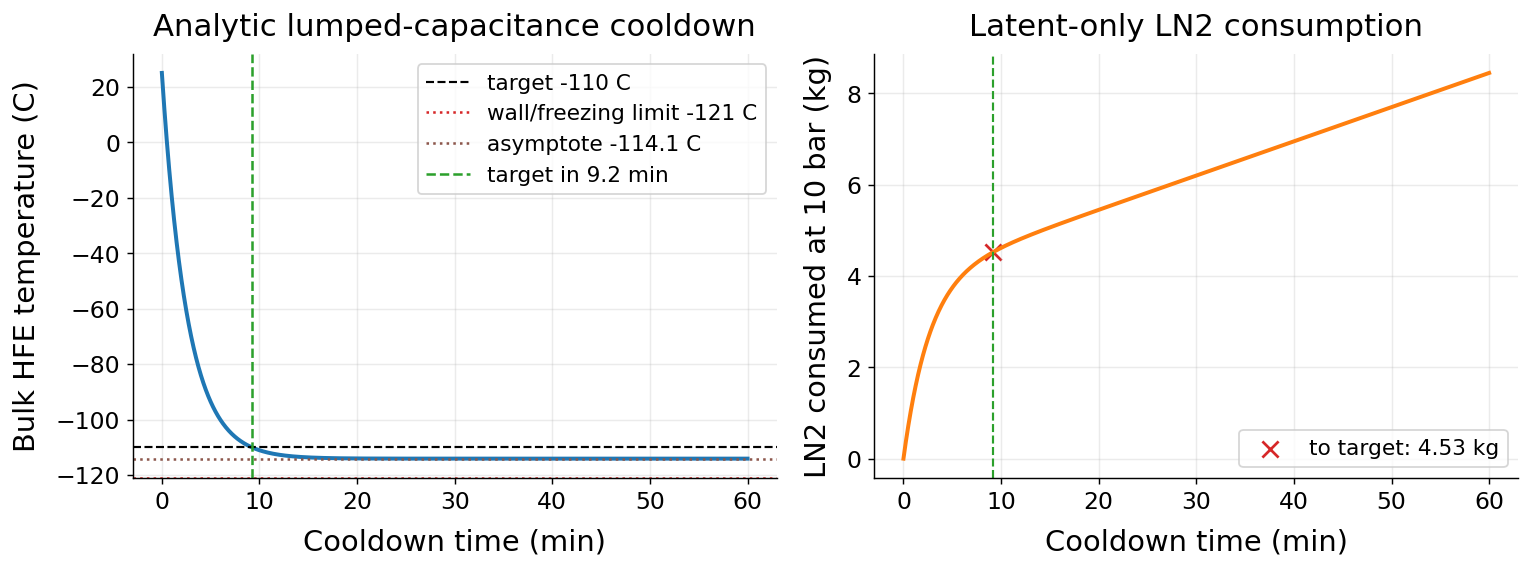

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

axes[0].plot(history["time_min"], history["bulk_temp_c"], color="C0", lw=2.2)
axes[0].axhline(inputs.target_temp_c, color="k", ls="--", lw=1.2, label="target -110 C")
axes[0].axhline(inputs.freeze_temp_c, color="C3", ls=":", lw=1.4, label="wall/freezing limit -121 C")
axes[0].axhline(result.equilibrium_temp_c, color="C5", ls=":", lw=1.4, label=f"asymptote {result.equilibrium_temp_c:.1f} C")
axes[0].axvline(result.time_to_target_min, color="C2", ls="--", lw=1.4, label=f"target in {result.time_to_target_min:.1f} min")
axes[0].set_xlabel("Cooldown time (min)")
axes[0].set_ylabel("Bulk HFE temperature (C)")
axes[0].set_title("Analytic lumped-capacitance cooldown")
axes[0].legend(fontsize=DISSERTATION_LEGEND_SIZE)

axes[1].plot(history["time_min"], history["ln2_consumed_kg"], color="C1", lw=2.2)
axes[1].scatter([result.time_to_target_min], [result.ln2_to_target_kg], color="C3", marker="x", s=80,
                label=f"to target: {result.ln2_to_target_kg:.2f} kg")
axes[1].axvline(result.time_to_target_min, color="C2", ls="--", lw=1.2)
axes[1].set_xlabel("Cooldown time (min)")
axes[1].set_ylabel("LN2 consumed at 10 bar (kg)")
axes[1].set_title("Latent-only LN2 consumption")
axes[1].legend(fontsize=DISSERTATION_LEGEND_SIZE)

plt.tight_layout()
plt.show()


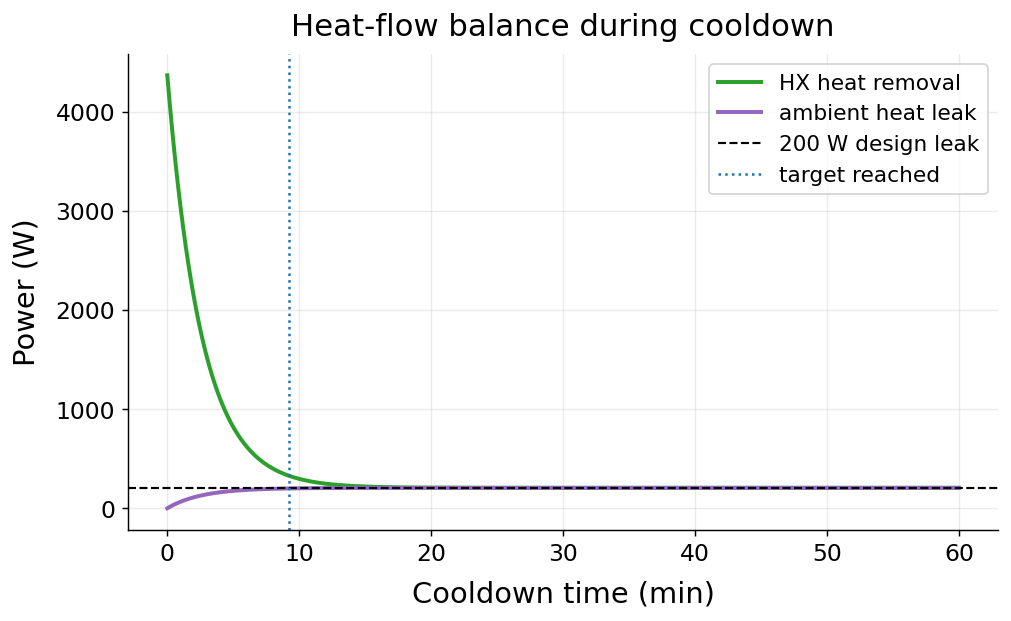

In [6]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))

ax.plot(history["time_min"], history["hx_power_w"], color="C2", lw=2.2, label="HX heat removal")
ax.plot(history["time_min"], history["heat_leak_w"], color="C4", lw=2.2, label="ambient heat leak")
ax.axhline(inputs.heat_leak_target_w, color="k", ls="--", lw=1.2, label="200 W design leak")
ax.axvline(result.time_to_target_min, color="C0", ls=":", lw=1.4, label="target reached")
ax.set_xlabel("Cooldown time (min)")
ax.set_ylabel("Power (W)")
ax.set_title("Heat-flow balance during cooldown")
ax.legend()
plt.tight_layout()
plt.show()


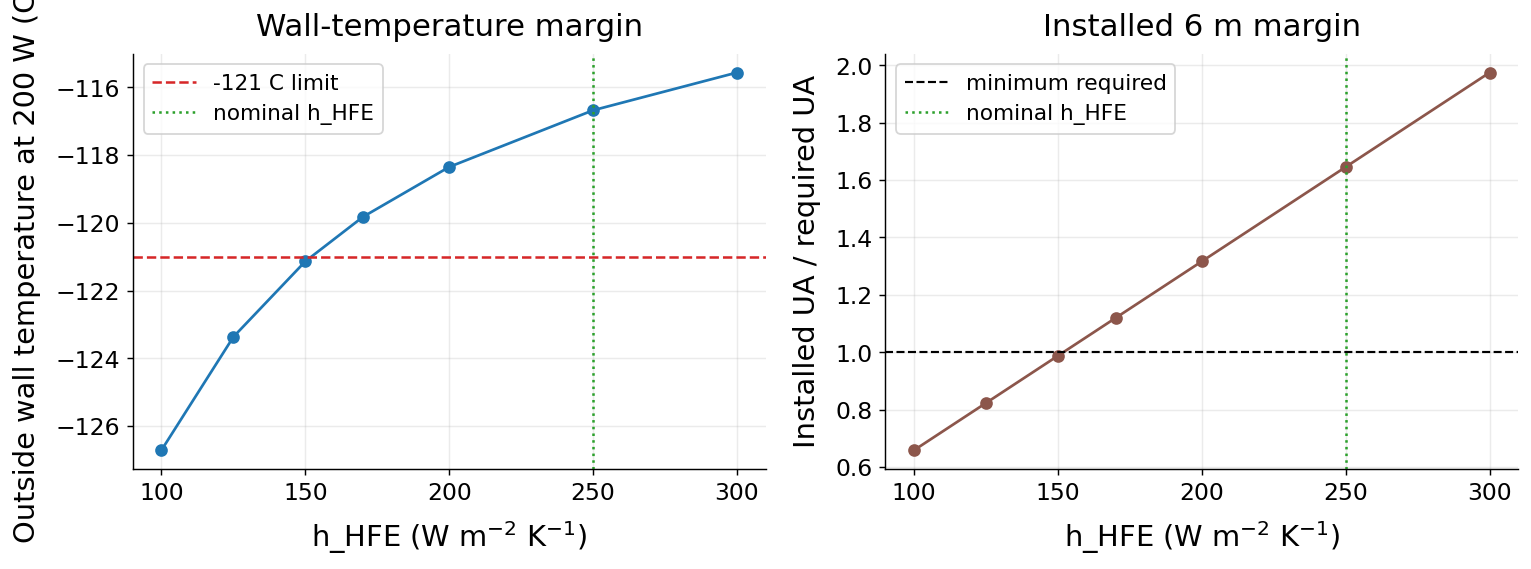

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

axes[0].plot(sensitivity["h_HFE_W_m2_K"], sensitivity["wall_temp_at_200w_C"], marker="o", color="C0")
axes[0].axhline(inputs.freeze_temp_c, color="C3", ls="--", lw=1.4, label="-121 C limit")
axes[0].axvline(inputs.hfe_htc_w_m2_k, color="C2", ls=":", lw=1.4, label="nominal h_HFE")
axes[0].set_xlabel("h_HFE (W m$^{-2}$ K$^{-1}$)")
axes[0].set_ylabel("Outside wall temperature at 200 W (C)")
axes[0].set_title("Wall-temperature margin")
axes[0].legend(fontsize=DISSERTATION_LEGEND_SIZE)

axes[1].plot(sensitivity["h_HFE_W_m2_K"], sensitivity["installed_margin"], marker="o", color="C5")
axes[1].axhline(1.0, color="k", ls="--", lw=1.2, label="minimum required")
axes[1].axvline(inputs.hfe_htc_w_m2_k, color="C2", ls=":", lw=1.4, label="nominal h_HFE")
axes[1].set_xlabel("h_HFE (W m$^{-2}$ K$^{-1}$)")
axes[1].set_ylabel("Installed UA / required UA")
axes[1].set_title("Installed 6 m margin")
axes[1].legend(fontsize=DISSERTATION_LEGEND_SIZE)

plt.tight_layout()
plt.show()


## Key Takeaway

For the correlation-backed nominal coefficient `h_HFE = 250 W m^-2 K^-1`, a `200 W` heat leak and an `11 K` allowable bulk-to-wall approach require about `3.6 m` of `1/4 in` tubing. The installed `6 m` coil is therefore above the simple steady requirement, and the critical coefficient for the installed length is only about `152 W m^-2 K^-1`. With the volume-based `3.06 L` HFE inventory and scaled HFE-7200 heat capacity, the same analytic lumped model predicts a cooldown from `25 C` to `-110 C` in roughly `9 min` with latent-only LN2 accounting.


## Tubing Pressure Drop Model

Integrated pressure-drop model.


## HFE-7200 tubing pressure-drop calculator

Corrected simple-physics model for estimating the liquid HFE-7200 pressure drop through the current loop geometry.

## Model and sources

For an incompressible single-phase liquid line, the pressure drop is modeled with Darcy-Weisbach pipe friction plus standard minor losses using the mean velocity head:

$$
\Delta P = \left(f_D\frac{L}{D} + K_\mathrm{minor}\right)\frac{\rho v^2}{2},\qquad v = \frac{Q}{A}.
$$

Here $f_D$ is the Darcy friction factor: a dimensionless wall-friction coefficient used in the Darcy-Weisbach equation. It is not the Fanning friction factor; for the same flow, $f_D = 4 f_\mathrm{Fanning}$. For laminar pipe flow, $f_D=64/Re$. A smooth-pipe Blasius fallback is included for higher Reynolds numbers, but the nominal design point here is laminar.

The Reynolds number can be computed either from dynamic viscosity, $Re=\rho vD/\mu$, or from kinematic viscosity, $Re=vD/\nu$, because $\nu=\mu/\rho$. This notebook starts from the documented kinematic-viscosity table, converts to dynamic viscosity with $\mu=\rho\nu$, and uses the dynamic-viscosity form; the two forms are checked to give the same value.

Here $K$ is a dimensionless loss coefficient. It says how many mean-velocity heads, $\rho v^2/2$, are lost by a fitting or pipe section. The pipe contribution is $K_\mathrm{pipe}=f_D L/D$; the aggregate fitting contribution is $K_\mathrm{minor}$ from bends, valves, contractions, and expansions. Larger $K$ means larger pressure drop at the same flow and diameter.

Fluid-property sources:

- Density: `analysis/docs/HFE 7200 Technical Data.pdf`, $\rho = 1000(1.4811 - 0.0023026T_C)$ kg/m$^3$.
- Kinematic viscosity: HFE-7200 table used in `analysis/notebooks/HFE_properties.ipynb`, transcribed from `analysis/docs/HFE Freezing Data.pdf`.

The old notebook used a fixed $\mu=6$ mPa s. At the nominal $-110^\circ$C point used below, log interpolation of the documented viscosity table gives $\nu=28.35$ cSt and $\mu=\rho\nu=49.18$ mPa s.

In [8]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PSI_PER_PA = 1.0 / 6894.757293168
PA_PER_BAR = 1.0e5


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'analysis' / 'docs').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root containing analysis/docs and data.')


REPO_ROOT = find_repo_root()

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


print(f'Repo root: {REPO_ROOT}')
print('Figure output: inline notebook display only')

Repo root: /home/aamy/Documents/hfe-system
Figure output: inline notebook display only


In [9]:
@dataclass(frozen=True)
class LineGeometry:
    length_m: float = 3.75
    od_in: float = 3 / 8
    wall_in: float = 0.035
    n_90: int = 6
    n_45: int = 0
    n_ball_valves: int = 1
    n_contractions: int = 1
    n_expansions: int = 1
    beta_contraction: float = 0.001
    beta_expansion: float = 0.001


@dataclass(frozen=True)
class HFE7200State:
    temperature_C: float = -110.0


@dataclass(frozen=True)
class LossCoefficients:
    K_90: float = 0.65
    K_45: float = 0.35
    K_ball: float = 0.04


HFE7200_VISCOSITY_TABLE = pd.DataFrame(
    {
        'temperature_C': [25.0, 0.0, -10.0, -20.0, -30.0, -40.0, -50.0, -60.0, -70.0, -100.0, -120.0],
        'kinematic_viscosity_cSt': [0.41, 0.67, 0.78, 0.93, 1.14, 1.42, 1.84, 2.48, 3.72, 12.47, 64.47],
    }
).sort_values('temperature_C')


def id_from_od_wall(od_in: float, wall_in: float) -> float:
    return (od_in - 2.0 * wall_in) * 0.0254


def hfe7200_density_kg_m3(temperature_C):
    temperature_C = np.asarray(temperature_C, dtype=float)
    return 1000.0 * (1.4811 - 0.0023026 * temperature_C)


def hfe7200_kinematic_viscosity_cst(temperature_C):
    """Return HFE-7200 kinematic viscosity by log interpolation of the reference table."""

    temperature_C = np.asarray(temperature_C, dtype=float)
    table_temperature = HFE7200_VISCOSITY_TABLE['temperature_C'].to_numpy(float)
    table_log_nu = np.log(HFE7200_VISCOSITY_TABLE['kinematic_viscosity_cSt'].to_numpy(float))

    if np.nanmin(temperature_C) < table_temperature.min() or np.nanmax(temperature_C) > table_temperature.max():
        raise ValueError(
            'Viscosity interpolation is only supported over '
            f'{table_temperature.min():.0f}..{table_temperature.max():.0f} C.'
        )

    return np.exp(np.interp(temperature_C, table_temperature, table_log_nu))


def hfe7200_dynamic_viscosity_pa_s(temperature_C):
    rho = hfe7200_density_kg_m3(temperature_C)
    nu_m2_s = hfe7200_kinematic_viscosity_cst(temperature_C) * 1.0e-6
    return rho * nu_m2_s


def darcy_friction_factor(Re):
    Re = np.asarray(Re, dtype=float)
    if np.any(Re <= 0.0):
        raise ValueError('Reynolds number must be positive.')

    laminar = 64.0 / Re
    turbulent = 0.3164 / Re**0.25  # Blasius smooth-pipe approximation.
    transition_weight = np.clip((Re - 2300.0) / (4000.0 - 2300.0), 0.0, 1.0)
    return (1.0 - transition_weight) * laminar + transition_weight * turbulent


def minor_loss_coefficient(geometry: LineGeometry, losses: LossCoefficients) -> float:
    return (
        geometry.n_90 * losses.K_90
        + geometry.n_45 * losses.K_45
        + geometry.n_ball_valves * losses.K_ball
        + geometry.n_contractions * 0.45 * (1.0 - geometry.beta_contraction)
        + geometry.n_expansions * (1.0 - geometry.beta_expansion) ** 2
    )


def pressure_drop_hfe7200(
    flow_L_min,
    *,
    geometry: LineGeometry = LineGeometry(),
    state: HFE7200State = HFE7200State(),
    losses: LossCoefficients = LossCoefficients(),
    diameter_m=None,
    minor_loss_scale: float = 1.0,
) -> pd.DataFrame:
    if diameter_m is None:
        diameter_m = id_from_od_wall(geometry.od_in, geometry.wall_in)

    flow_m3_s = np.asarray(flow_L_min, dtype=float) * 1.0e-3 / 60.0
    diameter_m = np.asarray(diameter_m, dtype=float)
    flow_m3_s, diameter_m = np.broadcast_arrays(flow_m3_s, diameter_m)
    flow_m3_s = np.ravel(flow_m3_s)
    diameter_m = np.ravel(diameter_m)

    rho = float(hfe7200_density_kg_m3(state.temperature_C))
    nu_cst = float(hfe7200_kinematic_viscosity_cst(state.temperature_C))
    mu_pa_s = float(hfe7200_dynamic_viscosity_pa_s(state.temperature_C))
    nu_m2_s = nu_cst * 1.0e-6

    area_m2 = np.pi * diameter_m**2 / 4.0
    velocity_m_s = flow_m3_s / area_m2
    Re = rho * velocity_m_s * diameter_m / mu_pa_s
    Re_from_kinematic = velocity_m_s * diameter_m / nu_m2_s
    if not np.allclose(Re, Re_from_kinematic, rtol=1.0e-12, atol=0.0):
        raise AssertionError('Dynamic- and kinematic-viscosity Reynolds forms disagree.')
    f_D = darcy_friction_factor(Re)

    K_pipe = f_D * geometry.length_m / diameter_m
    K_minor = minor_loss_scale * minor_loss_coefficient(geometry, losses)
    K_total = K_pipe + K_minor
    velocity_head_pa = rho * velocity_m_s**2 / 2.0
    dP_Pa = K_total * velocity_head_pa

    return pd.DataFrame(
        {
            'flow_L_min': flow_m3_s * 60.0 * 1000.0,
            'temperature_C': state.temperature_C,
            'density_kg_m3': rho,
            'kinematic_viscosity_cSt': nu_cst,
            'dynamic_viscosity_mPa_s': mu_pa_s * 1000.0,
            'diameter_m': diameter_m,
            'velocity_m_s': velocity_m_s,
            'Re': Re,
            'darcy_f': f_D,
            'K_pipe': K_pipe,
            'K_minor': K_minor,
            'K_total': K_total,
            'dP_Pa': dP_Pa,
            'dP_bar': dP_Pa / PA_PER_BAR,
            'dP_psi': dP_Pa * PSI_PER_PA,
        }
    )


def pressure_drop_envelope(
    diameters_m,
    *,
    flow_L_min: float = 4.0,
    geometry: LineGeometry = LineGeometry(),
    state: HFE7200State = HFE7200State(),
    minor_loss_scale_bounds: tuple[float, float] = (0.7, 1.3),
) -> pd.DataFrame:
    """Return a deterministic sensitivity band from aggregate minor-loss K uncertainty only."""

    diameters_m = np.asarray(diameters_m, dtype=float)
    pressure_samples = []

    for minor_loss_scale in minor_loss_scale_bounds:
        pressure_samples.append(
            pressure_drop_hfe7200(
                flow_L_min,
                geometry=geometry,
                state=state,
                diameter_m=diameters_m,
                minor_loss_scale=float(minor_loss_scale),
            )['dP_bar'].to_numpy(float)
        )

    pressure_samples = np.vstack(pressure_samples)
    return pd.DataFrame(
        {
            'diameter_m': diameters_m,
            'dP_low_bar': np.nanmin(pressure_samples, axis=0),
            'dP_high_bar': np.nanmax(pressure_samples, axis=0),
        }
    )

In [10]:
geometry = LineGeometry()
state = HFE7200State(temperature_C=-110.0)
losses = LossCoefficients()
actual_id_m = id_from_od_wall(geometry.od_in, geometry.wall_in)

nominal = pressure_drop_hfe7200(4.0, geometry=geometry, state=state, losses=losses).iloc[0]
actual_envelope = pressure_drop_envelope(np.array([actual_id_m]), geometry=geometry, state=state).iloc[0]

assert np.isclose(actual_id_m * 1000.0, 7.747, atol=0.001)
assert np.isclose(float(hfe7200_density_kg_m3(-110.0)), 1734.386, atol=0.01)
assert np.isclose(float(hfe7200_kinematic_viscosity_cst(-110.0)), 28.3538516, atol=1.0e-6)
assert np.isclose(float(hfe7200_dynamic_viscosity_pa_s(-110.0)) * 1000.0, 49.1765232, atol=0.005)
assert np.isclose(nominal['Re'], 386.4321, rtol=5.0e-4)
assert np.isclose(nominal['dP_bar'], 1.4841255, rtol=5.0e-4)

print('Sanity checks passed.')
print(f'Actual tubing ID = {actual_id_m * 1000.0:.3f} mm')
print(f'HFE-7200 density at -110 °C = {nominal["density_kg_m3"]:.2f} kg/m^3')
print(f'HFE-7200 kinematic viscosity at -110 °C = {nominal["kinematic_viscosity_cSt"]:.2f} cSt')
print(f'HFE-7200 dynamic viscosity at -110 °C = {nominal["dynamic_viscosity_mPa_s"]:.2f} mPa s')
print(f'Re(4 L/min, actual ID) = {nominal["Re"]:.0f}')
print(f'Delta P(4 L/min, actual ID) = {nominal["dP_bar"]:.3f} bar = {nominal["dP_psi"]:.2f} psi')
print(f'Minor-K sensitivity at actual ID = {actual_envelope["dP_low_bar"]:.3f}..{actual_envelope["dP_high_bar"]:.3f} bar')

Sanity checks passed.
Actual tubing ID = 7.747 mm
HFE-7200 density at -110 °C = 1734.39 kg/m^3
HFE-7200 kinematic viscosity at -110 °C = 28.35 cSt
HFE-7200 dynamic viscosity at -110 °C = 49.18 mPa s
Re(4 L/min, actual ID) = 386
Delta P(4 L/min, actual ID) = 1.484 bar = 21.53 psi
Minor-K sensitivity at actual ID = 1.456..1.512 bar


In [11]:
component_rows = pd.DataFrame(
    {
        'quantity': [
            'Flow rate',
            'Temperature',
            'Inner diameter',
            'Density',
            'Kinematic viscosity',
            'Dynamic viscosity',
            'Mean velocity',
            'Reynolds number',
            'Darcy friction factor',
            'Pipe loss coefficient',
            'Minor loss coefficient',
            'Total loss coefficient',
            'Pressure drop',
            'Pressure drop',
            'Sensitivity band at actual ID',
        ],
        'value': [
            nominal['flow_L_min'],
            nominal['temperature_C'],
            nominal['diameter_m'] * 1000.0,
            nominal['density_kg_m3'],
            nominal['kinematic_viscosity_cSt'],
            nominal['dynamic_viscosity_mPa_s'],
            nominal['velocity_m_s'],
            nominal['Re'],
            nominal['darcy_f'],
            nominal['K_pipe'],
            nominal['K_minor'],
            nominal['K_total'],
            nominal['dP_bar'],
            nominal['dP_psi'],
            np.nan,
        ],
        'unit': [
            'L/min',
            'C',
            'mm',
            'kg/m^3',
            'cSt',
            'mPa s',
            'm/s',
            '-',
            '-',
            '-',
            '-',
            '-',
            'bar',
            'psi',
            f'{actual_envelope["dP_low_bar"]:.3f}..{actual_envelope["dP_high_bar"]:.3f} bar',
        ],
    }
)

display(component_rows)

,quantity,value,unit
0,Flow rate,4.000000,L/min
1,Temperature,-110.000000,C
2,Inner diameter,7.747000,mm
3,Density,1734.386000,kg/m^3
4,Kinematic viscosity,28.353852,cSt
5,Dynamic viscosity,49.176523,mPa s
6,Mean velocity,1.414333,m/s
7,Reynolds number,386.432142,-
8,Darcy friction factor,0.165618,-
9,Pipe loss coefficient,80.168627,-


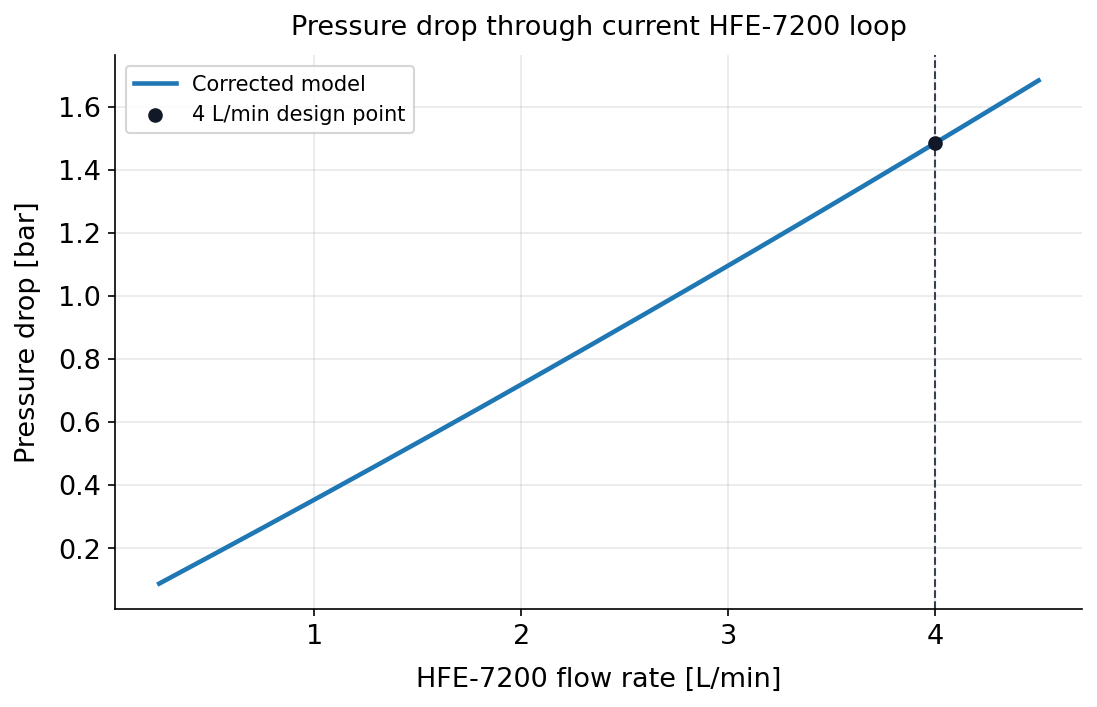

In [12]:
flows = np.linspace(0.25, 4.5, 180)
flow_df = pressure_drop_hfe7200(flows, geometry=geometry, state=state, losses=losses)

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
ax.plot(flow_df['flow_L_min'], flow_df['dP_bar'], color='#1f77b4', lw=2.2, label='Corrected model')
ax.scatter([nominal['flow_L_min']], [nominal['dP_bar']], color='#111827', zorder=4, label='4 L/min design point')
ax.axvline(4.0, color='#374151', ls='--', lw=1.0)
ax.set_xlabel('HFE-7200 flow rate [L/min]')
ax.set_ylabel('Pressure drop [bar]')
ax.set_title('Pressure drop through current HFE-7200 loop')
ax.legend(loc='upper left')

plt.show()

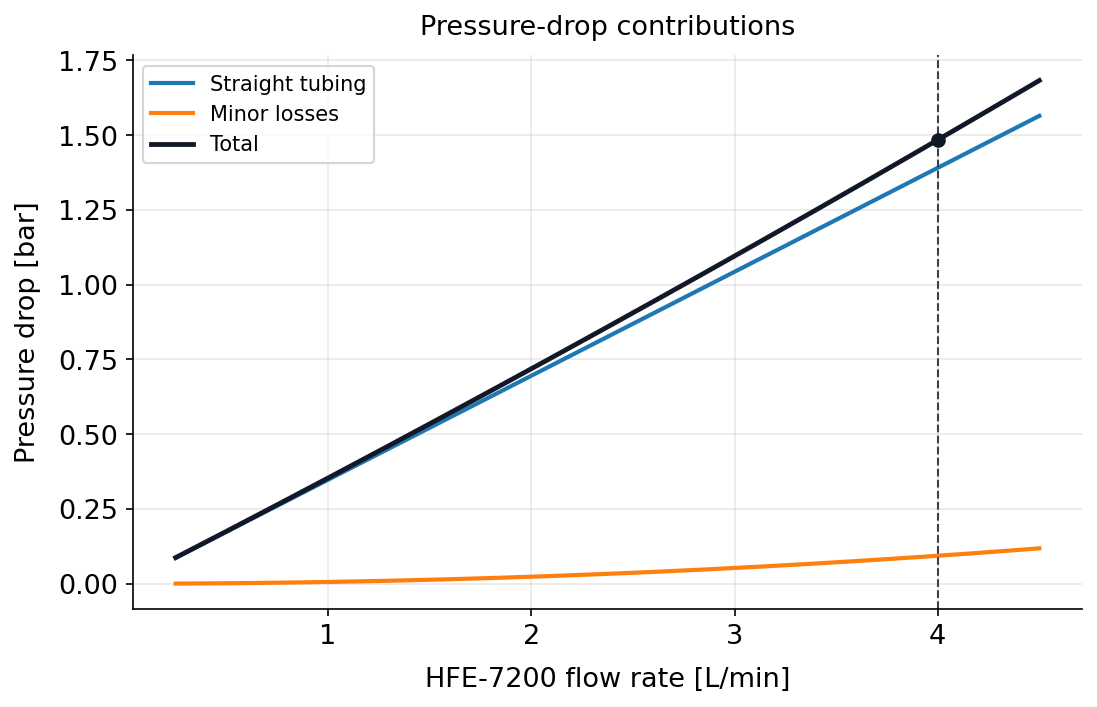

In [13]:
component_df = pressure_drop_hfe7200(flows, geometry=geometry, state=state, losses=losses)
rho = component_df['density_kg_m3'].to_numpy(float)
velocity = component_df['velocity_m_s'].to_numpy(float)
velocity_head_bar = rho * velocity**2 / 2.0 / PA_PER_BAR

component_df['dP_pipe_bar'] = component_df['K_pipe'] * velocity_head_bar
component_df['dP_minor_bar'] = component_df['K_minor'] * velocity_head_bar

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
ax.plot(flows, component_df['dP_pipe_bar'], lw=2.0, label='Straight tubing')
ax.plot(flows, component_df['dP_minor_bar'], lw=2.0, label='Minor losses')
ax.plot(flows, component_df['dP_bar'], color='#111827', lw=2.3, label='Total')
ax.scatter([nominal['flow_L_min']], [nominal['dP_bar']], color='#111827', zorder=4)
ax.axvline(4.0, color='#374151', ls='--', lw=1.0)
ax.set_xlabel('HFE-7200 flow rate [L/min]')
ax.set_ylabel('Pressure drop [bar]')
ax.set_title('Pressure-drop contributions')
ax.legend(loc='upper left')

plt.show()

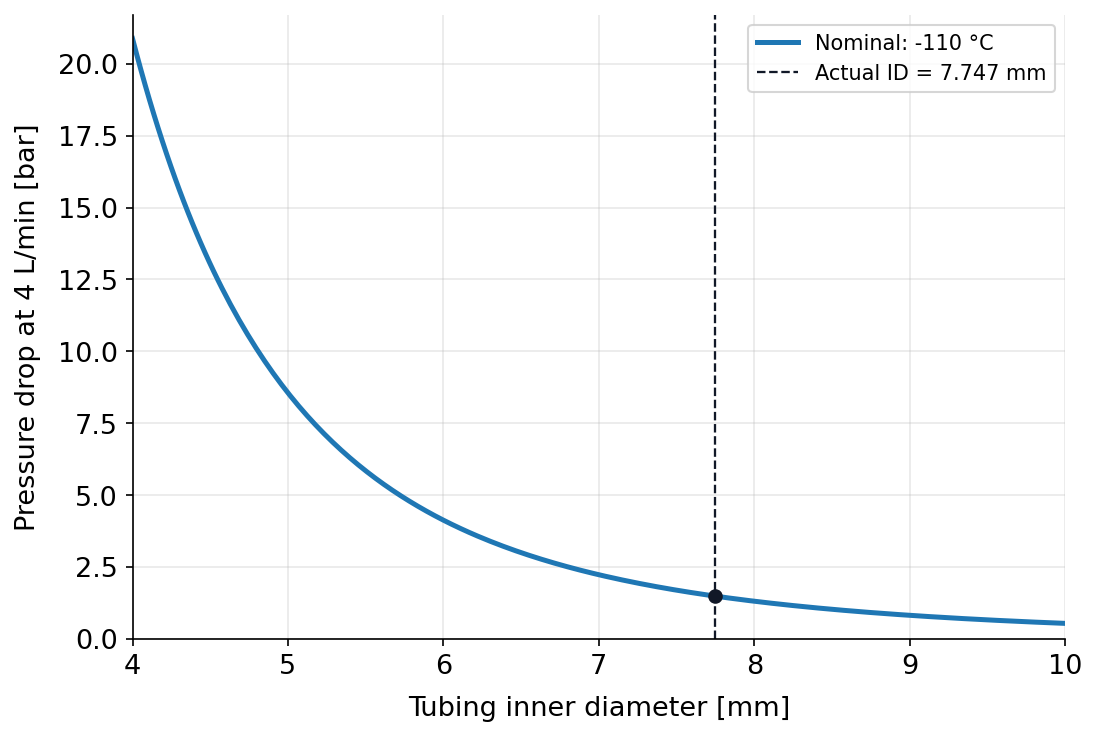

In [14]:
ids_mm = np.linspace(4.0, 10.0, 220)
ids_m = ids_mm / 1000.0
nominal_diameter_df = pressure_drop_hfe7200(4.0, geometry=geometry, state=state, losses=losses, diameter_m=ids_m)

fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
ax.plot(ids_mm, nominal_diameter_df['dP_bar'], color='#1f77b4', lw=2.4, label='Nominal: -110 °C')
ax.axvline(actual_id_m * 1000.0, color='#111827', ls='--', lw=1.1, label='Actual ID = 7.747 mm')
ax.scatter([actual_id_m * 1000.0], [nominal['dP_bar']], color='#111827', zorder=4)
ax.set_xlabel('Tubing inner diameter [mm]')
ax.set_ylabel('Pressure drop at 4 L/min [bar]')
ax.set_xlim(ids_mm.min(), ids_mm.max())
ax.set_ylim(0.0, max(1.25, float(nominal_diameter_df['dP_bar'].max()) * 1.04))
ax.legend(loc='upper right')

plt.show()


## Main design number

With the corrected default assumptions used here:

- HFE-7200 at $-110^\circ\mathrm{C}$
- documented HFE-7200 viscosity, log-interpolated to $\nu = 28.35~\mathrm{cSt}$, so $\mu = 49.18~\mathrm{mPa\,s}$ using the 3M density law
- $Q = 4~\mathrm{L\,min^{-1}}$
- 3/8 in OD x 0.035 in wall tubing, $D_\mathrm{ID}=7.747~\mathrm{mm}$
- $L = 3.75~\mathrm{m}$
- six 90 deg bends, one contraction, one expansion, and one ball valve

The pressure drop is **1.484 bar** (**21.53 psi**) at the design point. The Reynolds number is **386**, so the flow is laminar, not transitional. As a separate model check, varying only the aggregate minor-loss coefficient by $\pm30\%$ gives **1.46..1.51 bar** at the actual ID.

This replaces the older notebook value based on $\mu=6~\mathrm{mPa\,s}$ and the extra laminar kinetic-energy correction. Standard pipe-friction and minor-loss pressure drops use the mean velocity head directly, so no additional $4/3$ multiplier is applied.

In [15]:
def actual_id_case(minor_loss_scale: float, label: str) -> dict[str, float | str]:
    row = pressure_drop_hfe7200(
        4.0,
        geometry=geometry,
        state=state,
        diameter_m=actual_id_m,
        minor_loss_scale=minor_loss_scale,
    ).iloc[0]
    return {
        'case': label,
        'temperature_C': row['temperature_C'],
        'minor_loss_scale': minor_loss_scale,
        'diameter_mm': row['diameter_m'] * 1000.0,
        'Re': row['Re'],
        'K_pipe': row['K_pipe'],
        'K_minor': row['K_minor'],
        'K_total': row['K_total'],
        'dP_bar': row['dP_bar'],
        'dP_psi': row['dP_psi'],
    }


summary = pd.DataFrame(
    [
        actual_id_case(1.0, 'Nominal corrected model'),
        actual_id_case(0.7, 'Sensitivity lower bound: minor K x 0.7'),
        actual_id_case(1.3, 'Sensitivity upper bound: minor K x 1.3'),
    ]
)

display(summary.round(4))

,case,temperature_C,minor_loss_scale,diameter_mm,Re,K_pipe,K_minor,K_total,dP_bar,dP_psi
0,Nominal corrected model,-110.0,1.0,7.747,386.4321,80.1686,5.3876,85.5562,1.4841,21.5254
1,Sensitivity lower bound: minor K x 0.7,-110.0,0.7,7.747,386.4321,80.1686,3.7713,83.9399,1.4561,21.1188
2,Sensitivity upper bound: minor K x 1.3,-110.0,1.3,7.747,386.4321,80.1686,7.0038,87.1724,1.5122,21.9321
